# Fine-tune FinBERT on Financial PhraseBank

Grid search over `learning_rate × num_epochs` to identify the best FinBERT configuration. Selection criterion: **best validation macro-F1**.

Default grid:
- `learning_rate ∈ {1e-5, 2e-5, 5e-5}`
- `num_epochs ∈ {3, 4}`
- `batch_size = 16` (fixed, matches proposal)

= 6 configurations. **Total runtime: ~50-70 minutes on a Colab T4 GPU.** Each run saves its own predictions file to `predictions/sweep/` for inspection. After the sweep, the best config is retrained once and saved as the canonical `finbert_finetuned_predictions.csv`.

Why this grid is defensible: learning rate dominates BERT fine-tuning outcomes (Mosbach et al., 2021). Sweeping `lr` across an order of magnitude covers the commonly successful range. Epochs at 3 and 4 guard against over/underfitting on ~3,900 training sentences.

## Setup

In [1]:
import sys, os
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    if not os.path.exists('financial-sentiment-comparison'):
        !git clone https://github.com/maximusrome/financial-sentiment-comparison.git
    %cd financial-sentiment-comparison
    !pip install -q transformers==4.44.2 pandas scikit-learn pyarrow matplotlib seaborn

from pathlib import Path
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

import torch
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only"}')

Cloning into 'financial-sentiment-comparison'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 19 (delta 6), reused 18 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 20.66 KiB | 399.00 KiB/s, done.
Resolving deltas: 100% (6/6), done.
/content/financial-sentiment-comparison
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 97.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 128.2 MB/s eta 0:00:00
GPU: Tesla T4


In [2]:
from data_loader import build_and_save_split, load_split, SPLIT_PATH
if not SPLIT_PATH.exists():
    build_and_save_split()

Loading Financial PhraseBank from HuggingFace...
  Downloaded 666 KB
  Loaded 4838 unique sentences.
  Agreement tier distribution:
agreement_tier
100      2259
50-65     627
66-74     763
75-99    1189
  Label distribution:
label
neutral     2872
positive    1362
negative     604

Creating stratified 80/10/10 split...
split
train    3870
test      484
val       484

Saved split to /content/financial-sentiment-comparison/data/splits.parquet
Saved test metadata to /content/financial-sentiment-comparison/predictions/test_metadata.csv


## Run the sweep

In [3]:
from finbert_train import run_sweep

sweep_df = run_sweep(
    model_name='ProsusAI/finbert',
    output_name='finbert_finetuned',
    learning_rates=[1e-5, 2e-5, 5e-5],
    num_epochs_list=[3, 4],
    batch_size=16,
    seed=42,
)


=== Sweep: lr=1e-05, epochs=3 ===
Device: cuda
Config: TrainConfig(model_name='ProsusAI/finbert', output_name='finbert_finetuned_lr1e-05_ep3', max_length=128, batch_size=16, learning_rate=1e-05, num_epochs=3, weight_decay=0.01, warmup_ratio=0.1, seed=42, predictions_path='predictions/sweep/finbert_finetuned_lr1e-05_ep3.csv', metrics_path='results/tables/sweep/finbert_finetuned_lr1e-05_ep3.json', model_save_dir=None)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

  Epoch 1/3: train_loss=0.4554  val_acc=0.8574  val_macro_f1=0.8353
  Epoch 2/3: train_loss=0.2046  val_acc=0.8471  val_macro_f1=0.8315
  Epoch 3/3: train_loss=0.0785  val_acc=0.8492  val_macro_f1=0.8410

Best epoch: 3  Val macro-F1: 0.8410
Test accuracy:  0.8657
Test macro-F1:  0.8505
Elapsed: 269.3s
Saved predictions to predictions/sweep/finbert_finetuned_lr5e-05_ep3.csv
Saved metrics to results/tables/sweep/finbert_finetuned_lr5e-05_ep3.json

=== Sweep: lr=5e-05, epochs=4 ===
Device: cuda
Config: TrainConfig(model_name='ProsusAI/finbert', output_name='finbert_finetuned_lr5e-05_ep4', max_length=128, batch_size=16, learning_rate=5e-05, num_epochs=4, weight_decay=0.01, warmup_ratio=0.1, seed=42, predictions_path='predictions/sweep/finbert_finetuned_lr5e-05_ep4.csv', metrics_path='results/tables/sweep/finbert_finetuned_lr5e-05_ep4.json', model_save_dir=None)


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


  Epoch 1/4: train_loss=0.4616  val_acc=0.8678  val_macro_f1=0.8488
  Epoch 2/4: train_loss=0.2283  val_acc=0.8512  val_macro_f1=0.8437
  Epoch 3/4: train_loss=0.0919  val_acc=0.8533  val_macro_f1=0.8504
  Epoch 4/4: train_loss=0.0317  val_acc=0.8471  val_macro_f1=0.8418

Best epoch: 3  Val macro-F1: 0.8504
Test accuracy:  0.8533
Test macro-F1:  0.8318
Elapsed: 357.2s
Saved predictions to predictions/sweep/finbert_finetuned_lr5e-05_ep4.csv
Saved metrics to results/tables/sweep/finbert_finetuned_lr5e-05_ep4.json

Sweep results saved to results/tables/finbert_sweep.csv
 learning_rate  num_epochs  best_epoch_within_run  val_acc   val_f1  test_acc  test_f1  elapsed_s
       0.00001           3                      3 0.880165 0.872560  0.871901 0.859945      264.0
       0.00001           4                      3 0.878099 0.870585  0.865702 0.852744      357.3
       0.00002           3                      3 0.869835 0.865780  0.871901 0.861296      269.5
       0.00002           4        

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


  Epoch 1/3: train_loss=0.4808  val_acc=0.8678  val_macro_f1=0.8547
  Epoch 2/3: train_loss=0.2124  val_acc=0.8698  val_macro_f1=0.8618
  Epoch 3/3: train_loss=0.1217  val_acc=0.8802  val_macro_f1=0.8726

Best epoch: 3  Val macro-F1: 0.8726
Test accuracy:  0.8719
Test macro-F1:  0.8599
Elapsed: 269.2s
Saved predictions to predictions/finbert_finetuned_predictions.csv
Saved metrics to results/tables/finbert_finetuned_metrics.json


## Sweep results table

In [4]:
import pandas as pd
sweep_df = pd.read_csv('results/tables/finbert_sweep.csv')
sweep_df.round(4)

,learning_rate,num_epochs,best_epoch_within_run,val_acc,val_f1,test_acc,test_f1,elapsed_s
0,0.0,3,3,0.8802,0.8726,0.8719,0.8599,264.0
1,0.0,4,3,0.8781,0.8706,0.8657,0.8527,357.3
2,0.0,3,3,0.8698,0.8658,0.8719,0.8613,269.5
3,0.0,4,3,0.8595,0.8512,0.8657,0.8512,357.2
4,0.0,4,3,0.8533,0.8504,0.8533,0.8318,357.2
5,0.0,3,3,0.8492,0.8410,0.8657,0.8505,269.3


## Visualize the sweep

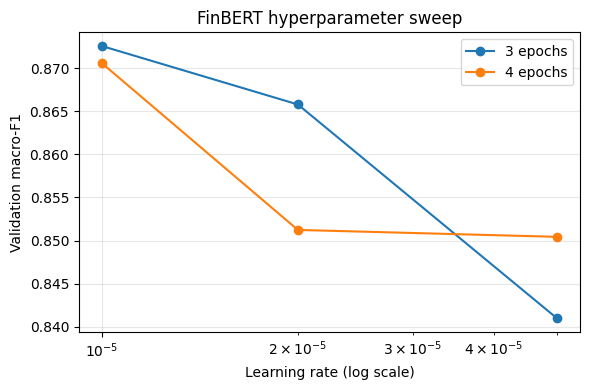

In [8]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 4))
for n_ep, group in sweep_df.groupby('num_epochs'):
    g = group.sort_values('learning_rate')
    ax.plot(g['learning_rate'], g['val_f1'], marker='o',
            label=f'{n_ep} epochs')
ax.set_xscale('log')
ax.set_xlabel('Learning rate (log scale)')
ax.set_ylabel('Validation macro-F1')
ax.set_title('FinBERT hyperparameter sweep')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/finbert_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## Final evaluation (best config retrained)

`run_sweep` already retrained the best config and saved it to `predictions/finbert_finetuned_predictions.csv`. Evaluate with the standard framework:

In [9]:
from evaluation import evaluate_predictions
result = evaluate_predictions('predictions/finbert_finetuned_predictions.csv')
print(f"Test accuracy:  {result['overall']['accuracy']:.4f}")
print(f"Test macro-F1:  {result['overall']['macro_f1']:.4f}\n")
print('By agreement tier:')
for tier, m in result['by_tier'].items():
    print(f"  tier={tier:6s}  acc={m['accuracy']:.4f}  macro_f1={m['macro_f1']:.4f}  (n={m['n']})")

Test accuracy:  0.8719
Test macro-F1:  0.8599

By agreement tier:
  tier=100     acc=0.9735  macro_f1=0.9574  (n=226)
  tier=75-99   acc=0.9000  macro_f1=0.8677  (n=120)
  tier=66-74   acc=0.7237  macro_f1=0.7364  (n=76)
  tier=50-65   acc=0.6290  macro_f1=0.6645  (n=62)


In [11]:
!zip -r /content/output.zip data predictions results
from google.colab import files
files.download('/content/output.zip')

  adding: data/ (stored 0%)
  adding: data/splits.parquet (deflated 16%)
  adding: predictions/ (stored 0%)
  adding: predictions/finbert_finetuned_predictions.csv (deflated 82%)
  adding: predictions/test_metadata.csv (deflated 63%)
  adding: predictions/sweep/ (stored 0%)
  adding: predictions/sweep/finbert_finetuned_lr1e-05_ep4.csv (deflated 82%)
  adding: predictions/sweep/finbert_finetuned_lr5e-05_ep4.csv (deflated 83%)
  adding: predictions/sweep/finbert_finetuned_lr2e-05_ep4.csv (deflated 82%)
  adding: predictions/sweep/finbert_finetuned_lr5e-05_ep3.csv (deflated 83%)
  adding: predictions/sweep/finbert_finetuned_lr1e-05_ep3.csv (deflated 82%)
  adding: predictions/sweep/finbert_finetuned_lr2e-05_ep3.csv (deflated 83%)
  adding: results/ (stored 0%)
  adding: results/tables/ (stored 0%)
  adding: results/tables/finbert_finetuned_metrics.json (deflated 47%)
  adding: results/tables/finbert_sweep.csv (deflated 52%)
  adding: results/tables/sweep/ (stored 0%)
  adding: results/tab

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>